<a href="https://colab.research.google.com/github/appling2024/MSP/blob/Liza_L/SemAn/WSD%20(example_for_taxonomy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 397.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.1 MB/s eta 0:00:00
  Created wheel for compress-fasttext: filename=compress_fasttext-0.1.5-py3-none-any.whl size=16098 sha256=c4f7424297c06bc219dc8e9adf194b10c142279f6c3087536ada46919fb468a9
  Stored in directory: /root/.cache/pip/wheels/90/ed/77/0a7fc5e08ff30e062f09c6904844a5911a9e30a7e5ec376890
Successfully built compress-fasttext
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scip

In [1]:
!pip install ruwordnet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.7 MB/s eta 0:00:00
  Created wheel for ruwordnet: filename=ruwordnet-0.0.6-py3-none-any.whl size=13168 sha256=5479b815cc488a33813050b4dfa62baa8259b027744b7ddffa30d2f34f895022
  Stored in directory: /root/.cache/pip/wheels/e7/2f/fb/2e3092dc5042dda374100a06724a287116adfc612e317df245
Successfully built ruwordnet
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.41
    Uninstalling SQLAlchemy-2.0.41:
      Successfully uninstalled SQLAlchemy-2.0.41
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [2]:
!ruwordnet download

downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [9]:
from ruwordnet import RuWordNet
wn = RuWordNet() #Здесь мы создаем объект (или экземпляр) класса
# RuWordNet и сохраняем его в переменной wn. Это значит, что wn теперь будет содержать все данные и методы этого объекта, которые мы можем использовать для работы с русского языка и его словарем.

o
гибридный - 	Использование WordNet для начальной разметки + дообучение на корпусе

In [4]:
len(wn.synsets), len(wn.senses)
#Синсет — это набор слов, которые имеют одно и то же значение или очень близкие значения. С помощью функции len() мы получаем количество этих синсетов.

(59905, 154111)

# Using the thesaurus

In [5]:
# в какие синсеты входит слово "замок"?
# два значения => два синсета, соответствующие этим значениям
for sense in wn.get_senses('замок'):
    print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [6]:
for sense in wn.get_senses('лук'):
    print(sense.synset)

Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)")
Synset(id="144347-N", title="ЗЕЛЕНЫЙ ЛУК")
Synset(id="108010-N", title="ЛУК (ОРУЖИЕ)")


In [7]:
for sense in wn.get_senses('класс'):
    print(sense.synset)

Synset(id="133202-N", title="КЛАСС ЖИВОТНЫХ, РАСТЕНИЙ")
Synset(id="140004-N", title="СОЦИАЛЬНЫЙ КЛАСС")
Synset(id="143645-N", title="КЛАСС, РАНГ (СТЕПЕНЬ, УРОВЕНЬ)")
Synset(id="115531-N", title="КЛАСС УЧЕНИКОВ")
Synset(id="115532-N", title="КЛАСС ДЛЯ ЗАНЯТИЙ")
Synset(id="120138-N", title="ТИП, ВИД, КЛАСС")


In [8]:
wn.get_senses('замок')[0].synset.hypernyms # слова, которые обозначают более общую категорию или класс, к которому принадлежат более специфичные термины, называемые гипонимами.

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [9]:
wn.get_senses('кот')[0].synset.hypernyms

[Synset(id="107876-N", title="САМЕЦ (ЖИВОТНОЕ)"),
 Synset(id="6804-N", title="ДОМАШНЯЯ КОШКА")]

In [10]:
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [11]:
wn.get_senses('авокадо')

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

In [12]:
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0] #берём самый первый гипероним
veg

Synset(id="348-N", title="ОВОЩИ")

In [13]:
veg.hyponyms #а тут уже смотрим какие гопонимы в овощах

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

## More relations

Домен - атрибут

In [14]:
print(wn['мяч'][0].synset.domains)

[Synset(id="109383-N", title="ИГРА (РАЗВЛЕЧЕНИЕ)"), Synset(id="1622-N", title="СПОРТ")]


In [15]:
import random
print(random.sample(wn['спорт'][0].synset.domain_items, 10))

[Synset(id="126949-N", title="СОВРЕМЕННОЕ ПЯТИБОРЬЕ"), Synset(id="148280-N", title="ПОДТЯГИВАНИЕ (УПРАЖНЕНИЕ)"), Synset(id="111417-N", title="БИАТЛОН"), Synset(id="152003-N", title="КОРОТКАЯ ПРОГРАММА"), Synset(id="5127-N", title="СПОРТИВНОЕ ЗВАНИЕ"), Synset(id="150326-V", title="БОЛЕТЬ ЗА СПОРТСМЕНА, КОМАНДУ"), Synset(id="135881-A", title="АВИАЦИОННЫЙ СПОРТ"), Synset(id="2498-N", title="СПОРТИВНЫЙ ИНВЕНТАРЬ"), Synset(id="143018-N", title="СКЕЙТБОРДИНГ"), Synset(id="124255-A", title="ВОЛАН ДЛЯ БАДМИНТОНА")]


Часть - целое

In [16]:
print(wn['автомобиль'][0].synset.meronyms)

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"), Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"), Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"), Synset(id="108798-N", title="КАПОТ МАШИНЫ")]


In [17]:
print(wn['страница'][0].synset.holonyms)

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"), Synset(id="5820-N", title="ТЕТРАДЬ")]


Класс-экземпляр

In [18]:
import random

In [19]:
print(wn['москва-река'][0].synset.classes)

[Synset(id="136791-N", title="РЕКИ РОССИЙСКОЙ ФЕДЕРАЦИИ")]


In [20]:
print(random.sample(wn['областной центр'][0].synset.instances, 10))

[Synset(id="100681-N", title="ВОРОНЕЖ"), Synset(id="105703-N", title="ПЕТРОПАВЛОВСК-КАМЧАТСКИЙ"), Synset(id="101032-N", title="ИРКУТСК"), Synset(id="102310-N", title="ОМСК"), Synset(id="102918-N", title="ТУЛА"), Synset(id="100244-N", title="БЛАГОВЕЩЕНСК"), Synset(id="100628-N", title="ВОЛГОГРАД"), Synset(id="102220-N", title="НОВОСИБИРСК"), Synset(id="101703-N", title="ЛИПЕЦК"), Synset(id="102373-N", title="ПЕНЗА")]


Предпосылки - выводы

In [21]:
print(wn['убить'][0].synset.premises)

[]


In [22]:
print(wn['завоевать'][0].synset.conclusions)

[Synset(id="106961-V", title="СОРЕВНОВАНИЕ, СОСТЯЗАНИЕ")]


Причины-следствия

In [23]:
print(wn['устать'][0].synset.causes)

[Synset(id="114599-V", title="УТОМИТЬ")]


In [24]:
print(wn['убить'][0].synset.effects)

[]


Частеречные синонимы

In [25]:
[s for ss in wn['убить'][0].synset.pos_synonyms for s in ss.senses]

[Sense(id="4628-N-113272", name="УБИЙСТВО"),
 Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ"),
 Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО"),
 Sense(id="4628-N-193509", name="МОКРУХА"),
 Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО"),
 Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО"),
 Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА"),
 Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")]

антонимы

In [26]:
wn['быстрый'][0].synset.antonyms

[Synset(id="118957-A", title="МЕДЛЕННЫЙ, НЕБЫСТРЫЙ")]

фразы и их составляющие

In [27]:
wn['быстрый'][0].phrases

[Sense(id="102679-N-129996", name="РЕКА БЫСТРАЯ"),
 Sense(id="8930-N-117128", name="БЫСТРОЕ ПИТАНИЕ"),
 Sense(id="9241-N-118631", name="БЫСТРЫЕ ШАХМАТЫ")]

In [28]:
wn['послужной список'][0].words

[Sense(id="106989-N-153921", name="СПИСОК")]

Однокоренные слова

In [29]:
wn['синий'][0].derivations

[Sense(id="109476-A-205236", name="СИНЕВАТЫЙ"),
 Sense(id="109476-A-689608", name="СИНЕНЬКИЙ"),
 Sense(id="109476-N-152798", name="СИНЕВА"),
 Sense(id="109476-N-152826", name="СИНЬ"),
 Sense(id="110418-N-148452", name="ПОСИНЕНИЕ"),
 Sense(id="110418-V-148453", name="ПОСИНЕТЬ"),
 Sense(id="110418-V-152799", name="СИНЕТЬ"),
 Sense(id="110419-V-152806", name="СИНИТЬ"),
 Sense(id="110419-V-175408", name="ПОДСИНИВАТЬ"),
 Sense(id="110765-N-152827", name="СИНЬКА"),
 Sense(id="111011-V-152799", name="СИНЕТЬ"),
 Sense(id="111011-V-183154", name="ЗАСИНЕТЬ")]

# Predicting hypernyms

In [30]:
!pip uninstall -y numpy
!pip install numpy==1.23.5
!pip install --force-reinstall --no-cache-dir gensim


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 93.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.3.1 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.23.5 which is incompatible.
db-dtypes 1.4.3 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
blosc2 3.4.0 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
bigframes 2.6.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
pymc 5.23.0 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 120.8 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


In [1]:
!pip install --upgrade git+https://github.com/avidale/compress-fasttext.git


  Cloning https://github.com/avidale/compress-fasttext.git to /tmp/pip-req-build-6zaaxdwi
  Running command git clone --filter=blob:none --quiet https://github.com/avidale/compress-fasttext.git /tmp/pip-req-build-6zaaxdwi
  Resolved https://github.com/avidale/compress-fasttext.git to commit 78f13cf7cd1924a1eb64d4931094225c1b6e7dbc
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import compress_fasttext
# библиотека для сжатия моделей fasttext
# github: https://github.com/avidale/compress-fasttext?tab=readme-ov-file


from collections import Counter
from sklearn.neighbors import KDTree

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import compress_fasttext

ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)


In [5]:
def vectorize(text):
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0)
    vec /= sum(vec**2) ** 0.5
    return vec
#чтобы представить целый текст как один вектор (например, для поиска похожих текстов).

def distance2vote(d, a=3, b=5):
    sim = np.maximum(0, 1 - d**2/2)
    return np.exp(-d**a) * sim **b

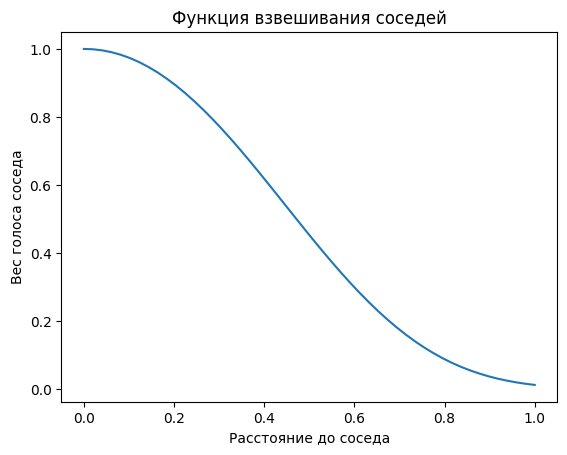

In [6]:
x = np.linspace(0, 1)
plt.plot(x, distance2vote(x))
plt.xlabel('Расстояние до соседа')
plt.ylabel('Вес голоса соседа')
plt.title('Функция взвешивания соседей');

    Показывает, как вес голоса зависит от расстояния (см. график).

    Чем ближе к 0, тем вес больше — это важно для алгоритмов типа k-NN (k ближайших соседей).

In [7]:
from tqdm.auto import tqdm, trange

In [10]:
words, vectors, synset_ids = [], [], []
for synset in tqdm(wn.synsets): # в цикле перебираем все синсеты тезауруса
    if synset.part_of_speech != 'V': # если не глагол - пропускаем
        continue
    for sense in synset.senses: # для смыслов данного синсета
        words.append(sense.name) # добавляем слово
        vectors.append(vectorize(sense.name)) # добавляем вектор этого слова
        synset_ids.append(synset.id) # добавляем id синсета
vectors = np.stack(vectors) # объединяем вектора, получаем трёхмерное пространство
#tree = KDTree(vectors) # на основе этого пространства строим дерево

  0%|          | 0/59905 [00:00<?, ?it/s]

In [11]:
tree = KDTree(vectors) # на основе этого пространства строим дерево

Мы ищем 100 ближайших по смыслу глаголов к слову «кудахтать».
Сначала превращаем слово в вектор (vectorize), потом спрашиваем у KDTree, какие слова рядом.
ids — это индексы найденных слов, dists — расстояния (насколько они близки). Смотрим гиперонимы (более общие понятия) для каждого найденного слова.
И голосуем за гипероним — чем ближе слово (меньше distance), тем больше голос (distance2vote(distance)).

In [12]:
votes = Counter()
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100)
for idx, distance in zip(ids[0], dists[0]):
    for hyper in wn[synset_ids[idx]].hypernyms:
        votes[hyper.id] += distance2vote(distance)
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms])

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
БУРЧАТЬ ['БОРМОТАТЬ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
БРАТЬСЯ ['ПОЛУЧИТЬ В РАСПОРЯЖЕНИЕ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ 

In [13]:
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


# Найди лишнее
ДИВАН, ШКАФ, ЛАМПА, СТОЛ

поиск наименьшего общего гиперонима — то есть, какое самое близкое общее понятие связывает пару слов.

In [14]:
import math


def get_all_hypernyms(wn, word, max_level=100): #Эта функция для слова (например, «диван») находит всех его гиперонимов — более общие понятия.
    front = [sense.synset for sense in wn.get_senses(word)]
    levels = {}
    for level in range(max_level):
        if not front:
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                levels[synset.id] = level
                new_front.extend(synset.hypernyms)
        front = new_front
    return levels

def get_closest_common(levels1, levels2):
    #Find the closest common hypernym and sum of distances to it"""
    result = None
    result_distance = math.inf
    for id, distance in levels1.items():
        if id in levels2:
            total = distance + levels2[id]
            if total < result_distance:
                result_distance = total
                result = id
    return result, result_distance

In [15]:
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']
print('\t\t', '\t'.join(words))
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


Меньше число = ближе смысл.
Например, «диван» и «стол» → расстояние 3, значит они близкие по смыслу в тезаурусе.

Лампа лишее??? Остальные — это мебель для хранения/сидения, а лампа — техническое устройство, совсем из другой категории.

In [16]:
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title) # видимо, наиболее близкий общий гипероним!

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [17]:
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


In [18]:
wn["149201-N"].hypernyms

[Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО"),
 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")]

In [19]:
for k, v in get_all_hypernyms(wn, 'стол').items():
    print(k, v, wn[k])

146834-N 0 Synset(id="146834-N", title="СТОЛ ДЛЯ ЕДЫ")
107294-N 0 Synset(id="107294-N", title="СТОЛ")
106554-N 1 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
1253-N 1 Synset(id="1253-N", title="МЕБЕЛЬ")
147133-N 2 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
130019-N 2 Synset(id="130019-N", title="НЕПРОДОВОЛЬСТВЕННЫЕ ТОВАРЫ")
146828-N 2 Synset(id="146828-N", title="ПРЕДМЕТ ИНТЕРЬЕРА")
9059-N 2 Synset(id="9059-N", title="ПРОДУКЦИЯ ДЕРЕВООБРАБОТКИ")
147134-N 3 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
1252-N 3 Synset(id="1252-N", title="ПОТРЕБИТЕЛЬСКИЕ ТОВАРЫ")
56-N 3 Synset(id="56-N", title="ПРОМЫШЛЕННАЯ ПРОДУКЦИЯ")
562-N 3 Synset(id="562-N", title="ТОВАР")
106507-N 3 Synset(id="106507-N", title="ПРОДУКТ ПРОИЗВОДСТВА")
153782-N 4 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")
106505-N 4 Synset(id="106505-N", title="ПРОДУКТ ТРУДА")


# Word sense disambiguation

зАмок или замОк ?

Примитивный алгоритм: для каждого значения находим синонимы и проверяем, какие ближе по fasttext-эмбеддингу к словам контекста.

Для верности, стоило бы кроме синонимов взять ещё и ко-гипонимы.

In [20]:
!pip install razdel

In [21]:
import razdel

In [22]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [23]:
def disambiguate(word, context):
    candidates = [s.synset for s in wn[word]]
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word))
    candidate_vectors = [
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates
    ]
    scores = [np.dot(text_vector, v) for v in candidate_vectors]
    return dict(zip(scores, candidates))

disambiguate(word, context)

{0.4421322748905842: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.55319632362594: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

In [24]:
context = '''Издали видны королевский замок Вавель и кафедральный собор Святых Вацлава и Станислава
― настоящие шедевры зодчества.'''
disambiguate(word, context)

{0.6623339070392336: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.5569728387813146: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}